Upgrade the hydroclimate database to the latest structure

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
id = 0
#table_name = "T_LOADING_Results"
table_name = "T_RECH_Results"
#table_name = "T_NUCON_Results"
#table_name = "T_NSOIL_Results"
#table_name = "T_NFERTILIZER_Results"
#table_name = "T_P_Results"

result_database_file_parallel = r"D:\imWEBs\test\05_SubareaBasedModel\Model01\output\scenario_2\scenario_2.db3"
result_database_file_noparallel = r"D:\imWEBs\test\05_SubareaBasedModel\Model01\output\scenario_2\scenario_2_parallel_old_hydroclimate.db3"

In [3]:
def create_connection(db_file):
    try:
        conn = sqlite3.connect(db_file)
        return conn
    except Exception as e:
        print(e)
        return None

def run_sql(conn, create_table_sql):
    try:
        c = conn.cursor()
        c.execute(create_table_sql)
    except Exception as e:
        print(e)

def get_columns(conn, table_name):    
    query = f"PRAGMA table_info({table_name})" 
    df = pd.read_sql_query(query,conn)
    return df['name'].to_list()

def get_data(conn, table_name, column, id):
    query = f"SELECT Time,{column} FROM {table_name} where ID={id}" 
    return pd.read_sql_query(query,conn, parse_dates=["Time"], index_col="Time")

def r_squared(y, y_hat):
    y_bar = y.mean()
    ss_tot = ((y - y_bar) ** 2).sum()
    ss_res = ((y - y_hat) ** 2).sum()
    return 1 - (ss_res / ss_tot)


['Time', 'ID', 'QS', 'QI', 'QG', 'QT', 'Q_m3', 'Q_mm']
R2 = no parallel    NaN
parallel       1.0
dtype: float64


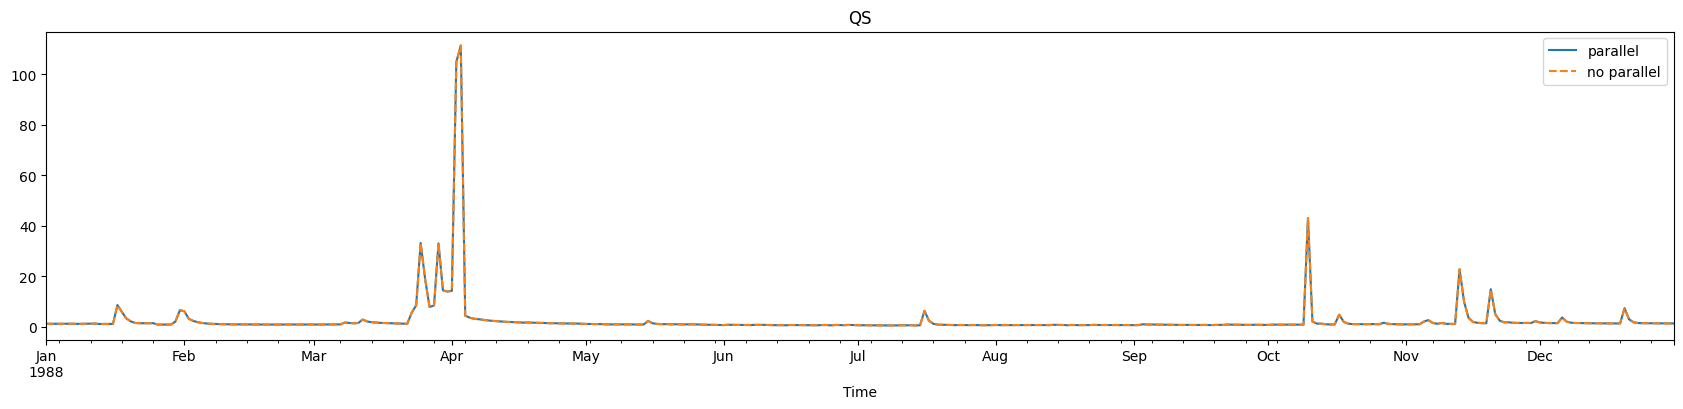

R2 = no parallel    NaN
parallel       1.0
dtype: float64


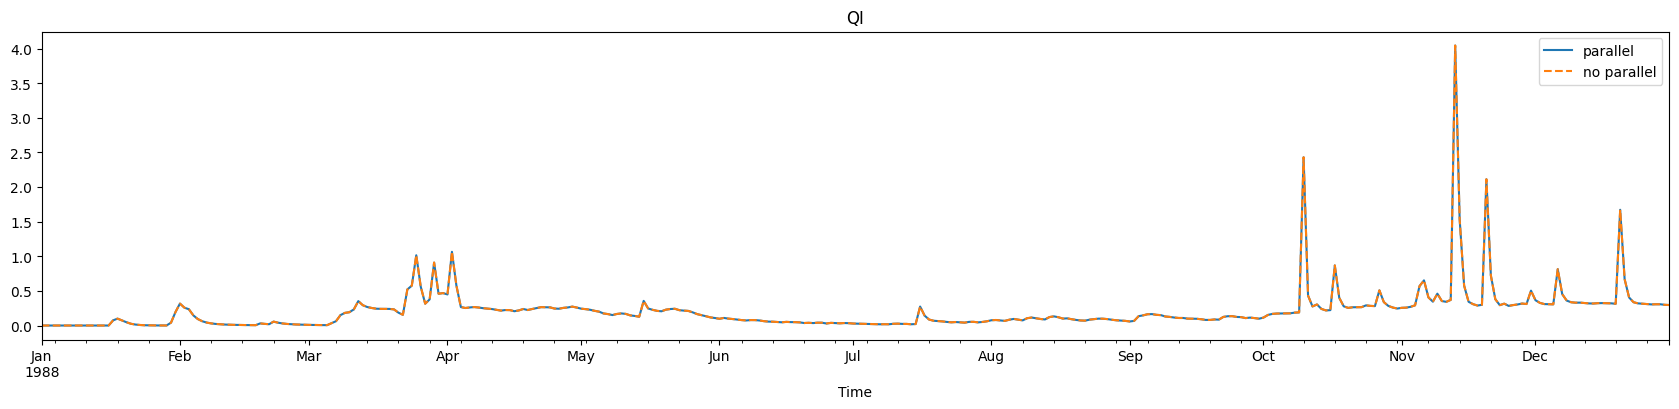

R2 = no parallel    NaN
parallel       1.0
dtype: float64


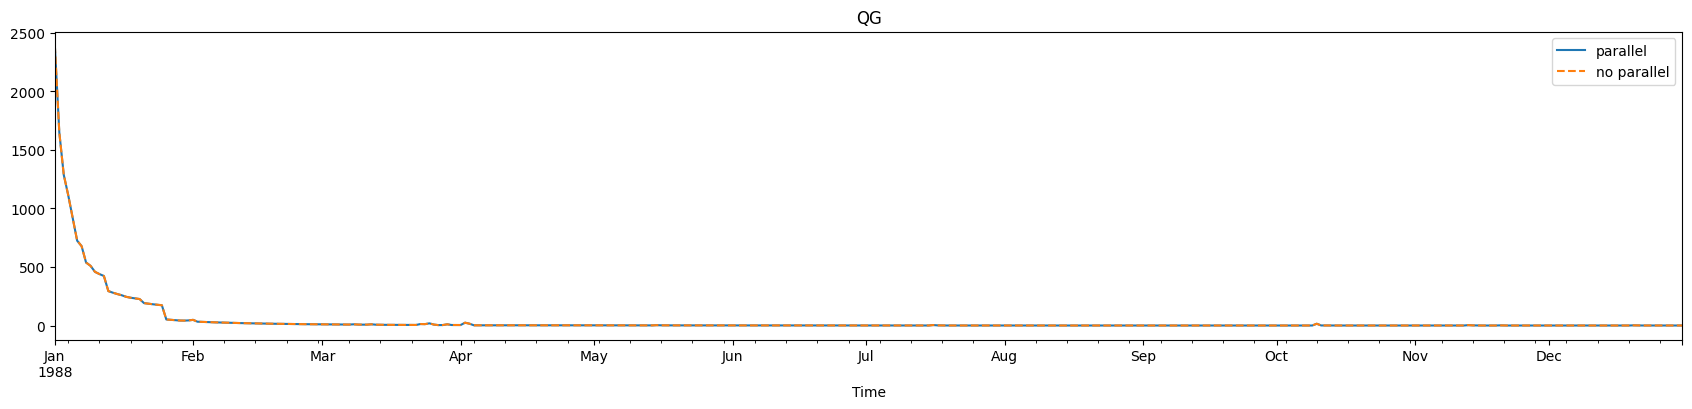

R2 = no parallel    NaN
parallel       1.0
dtype: float64


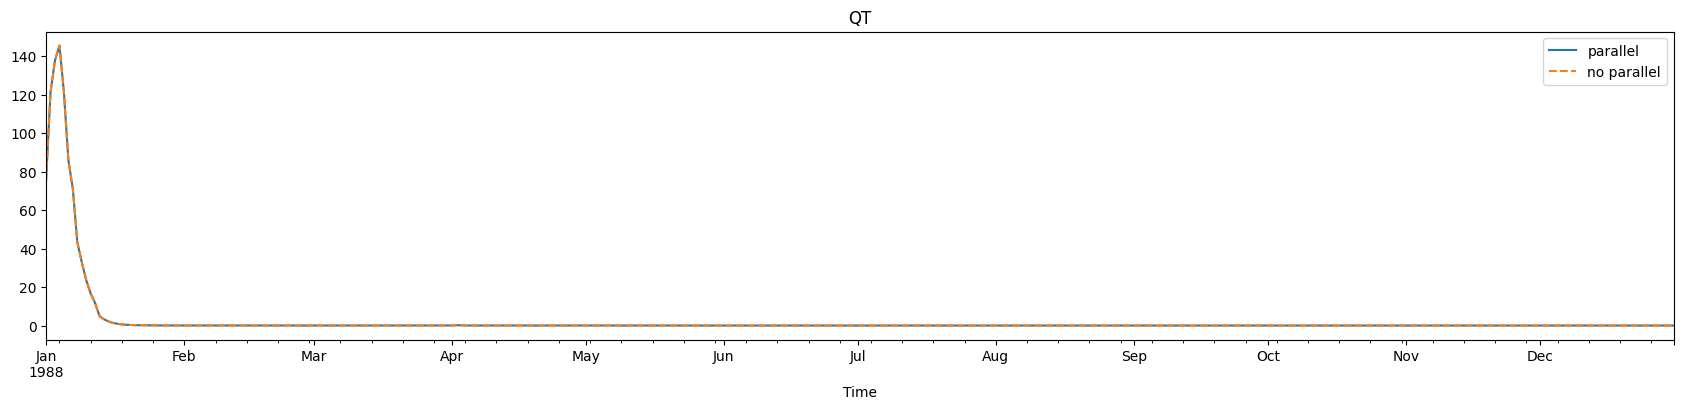

R2 = no parallel    NaN
parallel       1.0
dtype: float64


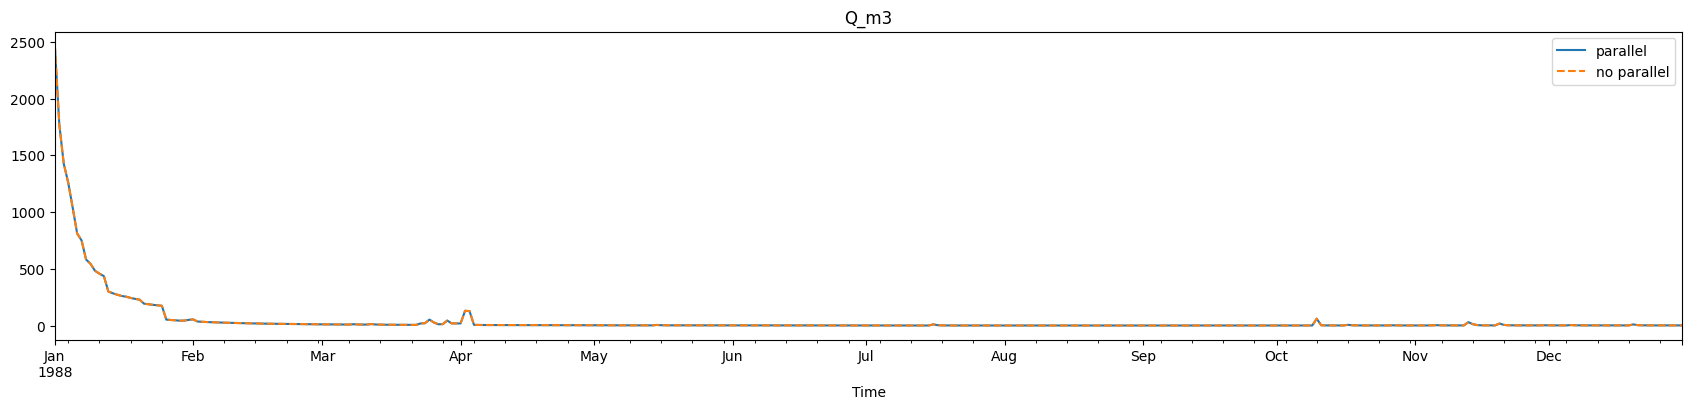

R2 = no parallel    NaN
parallel       1.0
dtype: float64


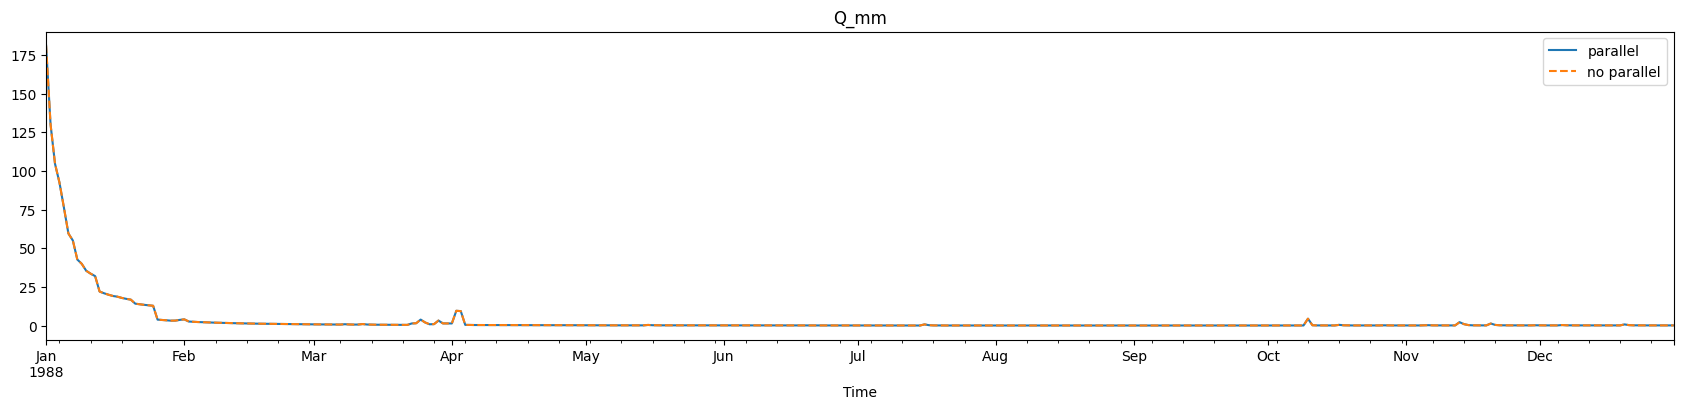

In [4]:
conn = create_connection(result_database_file_parallel)
conn_no_parallel = create_connection(result_database_file_noparallel)

with conn, conn_no_parallel:
    if conn is not None:
        columns = get_columns(conn, table_name)
        print(columns)
        for col in columns:
            #skip Time and ID column
            if col == "Time" or col == "ID":
                continue


            #get data and plot
            df1 = get_data(conn, table_name, col, id)
            df1.columns = ['parallel']
            ax = df1.plot(figsize=(21,4), title=col)

            df2 = get_data(conn_no_parallel, table_name, col, id)
            df2.columns = ['no parallel']
            df2.plot(ax = ax, linestyle="--")

            #calculate R2
            print(f"R2 = {r_squared(df1, df2)}")
            plt.show()    

            fig = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.07)
            fig.add_trace(go.Scatter(x=df1.index, y=df1[df1.columns[0]], name='New'), row=1, col=1)
            fig.add_trace(go.Scatter(x=df2.index, y=df2[df2.columns[0]], name='Old'), row=1, col=1)
            fig.update_yaxes(title_text=col, row=1, col=1)
            fig.update_layout(margin=dict(l=20, r=20, t=20, b=20), showlegend=True)

            fig.show()